<h1>Learning with <b>selected</b> data</h1>

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


FEATURES = ["RR_l_0", "RR_l_0/RR_l_1", "RR_r_0", "R_val", "P_val", "signal_std"]

# 1) Load your existing 80% learning data
learn_df = pd.read_csv("original_selected_features_data/learn_valid_80.csv")

# 2) Split into train/validation
X_learn = learn_df[FEATURES]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)

# 3) Train Random Forest on the training portion
rf_selected_features = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_selected_features.fit(X_train, y_train)

# 4) Validate
y_pred = rf_selected_features.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

Validation accuracy: 0.978125
Confusion matrix:
 [[157   3]
 [  4 156]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       160
           1       0.98      0.97      0.98       160

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320



In [50]:
test_df = pd.read_csv("original_selected_features_data/test_20.csv")

X_test, y_test = test_df[FEATURES], test_df["label"]

# Evaluate on the 20% test set
y_pred = rf_selected_features.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Test accuracy: 0.96
Confusion matrix:
 [[197   3]
 [ 13 187]]
Classification report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       200
           1       0.98      0.94      0.96       200

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



<h1>Learning with <b>tsne</b> data</h1>

In [51]:
# 1) Load your existing 80% learning data
learn_df = pd.read_csv("tsne_data/learn_valid_80.csv")

# 2) Split into train/validation
X_learn = learn_df[["tsne_x", "tsne_y"]]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)

# 3) Train Random Forest on the training portion
rf_tsne = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_tsne.fit(X_train, y_train)

# 4) Validate
y_pred = rf_tsne.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

Validation accuracy: 0.965625
Confusion matrix:
 [[156   4]
 [  7 153]]
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       160
           1       0.97      0.96      0.97       160

    accuracy                           0.97       320
   macro avg       0.97      0.97      0.97       320
weighted avg       0.97      0.97      0.97       320



In [52]:
test_df = pd.read_csv("tsne_data/test_20.csv")

X_test, y_test = test_df[["tsne_x", "tsne_y"]], test_df["label"]

# Evaluate on the 20% test set
y_pred = rf_tsne.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Test accuracy: 0.945
Confusion matrix:
 [[194   6]
 [ 16 184]]
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95       200
           1       0.97      0.92      0.94       200

    accuracy                           0.94       400
   macro avg       0.95      0.95      0.94       400
weighted avg       0.95      0.94      0.94       400



<h1>Learning with <b>all</b> data</h1>

In [53]:
learn_df = pd.read_csv("original_all_features_data/learn_valid_80.csv")

# keep only numeric columns
numeric_cols = learn_df.select_dtypes(include=[np.number]).columns

# features = all numeric columns except label (in case label is numeric)
feature_cols = numeric_cols.drop("label") if "label" in numeric_cols else numeric_cols

X_learn = learn_df[feature_cols]
y_learn = learn_df["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_learn, y_learn, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn
)

# 3) Train Random Forest on the training portion
rf_all_features = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_all_features.fit(X_train, y_train)

# 4) Validate
y_pred = rf_all_features.predict(X_valid)
print("Validation accuracy:", accuracy_score(y_valid, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

Validation accuracy: 0.99375
Confusion matrix:
 [[160   0]
 [  2 158]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       160
           1       1.00      0.99      0.99       160

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



In [54]:
test_df = pd.read_csv("original_all_features_data/test_20.csv")

X_test, y_test = test_df[feature_cols], test_df["label"]

# Evaluate on the 20% test set
y_pred = rf_all_features.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Test accuracy: 0.995
Confusion matrix:
 [[200   0]
 [  2 198]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       200
           1       1.00      0.99      0.99       200

    accuracy                           0.99       400
   macro avg       1.00      0.99      0.99       400
weighted avg       1.00      0.99      0.99       400



<h1>Optimizing <b>all</b> data set</h1>

In [55]:
# Grid search for Random Forest hyperparameters
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate best model on validation set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_valid)
print(f"\nValidation accuracy: {accuracy_score(y_valid, y_pred):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification report:\n", classification_report(y_valid, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.9977

Validation accuracy: 0.9938
Confusion matrix:
 [[160   0]
 [  2 158]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       160
           1       1.00      0.99      0.99       160

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



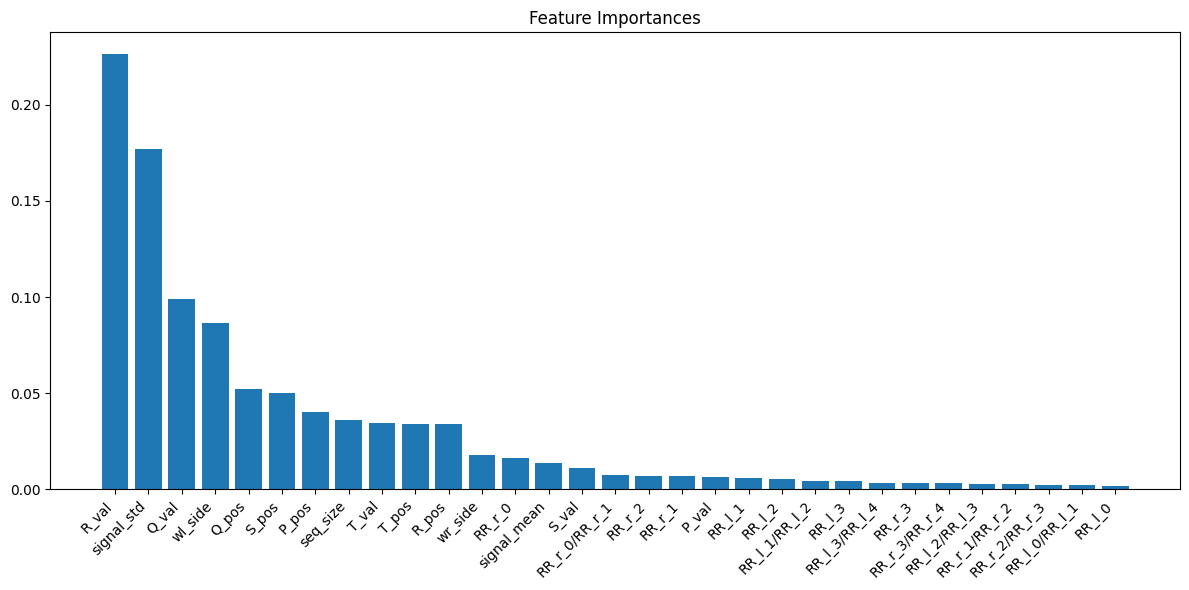


Top 10 most important features:
1. R_val: 0.2263
2. signal_std: 0.1771
3. Q_val: 0.0988
4. wl_side: 0.0867
5. Q_pos: 0.0523
6. S_pos: 0.0502
7. P_pos: 0.0405
8. seq_size: 0.0359
9. T_val: 0.0347
10. T_pos: 0.0343


In [56]:
# Feature importance visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best model
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print top 10 features
print("\nTop 10 most important features:")
for i in range(min(10, len(importances))):
    print(f"{i+1}. {feature_cols[indices[i]]}: {importances[indices[i]]:.4f}")

<h1>Visualization of Decision Boundaries (t-SNE data only)</h1>

c:\Users\Ugne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


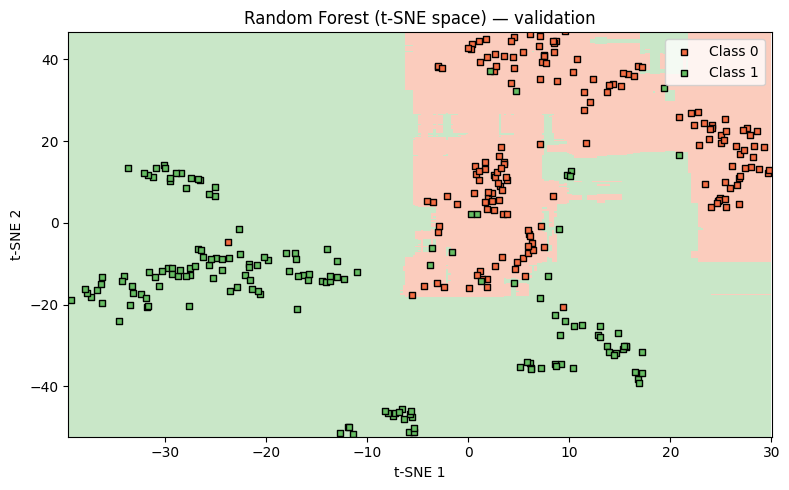

In [57]:
# Note: This visualization only works with t-SNE data (2D)
# We need to reload the t-SNE dataset and retrain for visualization

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Reload t-SNE data
learn_df_tsne = pd.read_csv("tsne_data/learn_valid_80.csv")
X_learn_tsne = learn_df_tsne[["tsne_x", "tsne_y"]]
y_learn_tsne = learn_df_tsne["label"]

X_train_tsne, X_valid_tsne, y_train_tsne, y_valid_tsne = train_test_split(
    X_learn_tsne, y_learn_tsne, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn_tsne
)

# Train RF for visualization
rf_viz = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_viz.fit(X_train_tsne, y_train_tsne)

# Prepare grid
X_all_tsne = pd.concat([X_train_tsne, X_valid_tsne], axis=0)
pad = 1.0
x_min = X_all_tsne["tsne_x"].quantile(0.01) - pad
x_max = X_all_tsne["tsne_x"].quantile(0.99) + pad
y_min = X_all_tsne["tsne_y"].quantile(0.01) - pad
y_max = X_all_tsne["tsne_y"].quantile(0.99) + pad

h = 0.25
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = rf_viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
bg_cmap = ListedColormap(["#f46d43", "#66bd63"])

plt.figure(figsize=(8, 5))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

classes = np.unique(pd.concat([y_train_tsne, y_valid_tsne]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

# Plot validation points
for cls in classes:
    m = y_valid_tsne == cls
    plt.scatter(X_valid_tsne.loc[m, "tsne_x"], X_valid_tsne.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=25, marker="s", label=f"Class {cls}")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Random Forest (t-SNE space) — validation")
plt.legend()
plt.tight_layout()
plt.show()

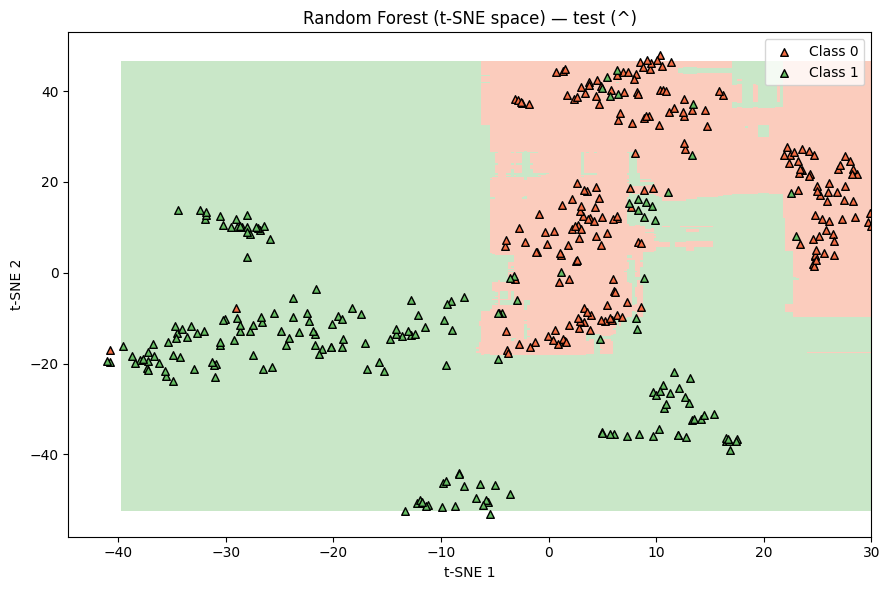

In [58]:
# Test set visualization
test_df_tsne = pd.read_csv("tsne_data/test_20.csv")
X_test_tsne = test_df_tsne[["tsne_x", "tsne_y"]]
y_test_tsne = test_df_tsne["label"]

# Extend grid to include test data
X_all_full = pd.concat([X_train_tsne, X_valid_tsne, X_test_tsne], axis=0)

plt.figure(figsize=(9, 6))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

classes = np.unique(pd.concat([y_train_tsne, y_valid_tsne, y_test_tsne]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

# Plot test points
for cls in classes:
    m = y_test_tsne == cls
    plt.scatter(X_test_tsne.loc[m, "tsne_x"], X_test_tsne.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=30, marker="^", label=f"Class {cls}")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Random Forest (t-SNE space) — test (^)")
plt.legend()
plt.tight_layout()
plt.show()

=== MISCLASSIFICATION ANALYSIS ===

Total misclassified: 2 out of 400
Misclassification rate: 0.50%

--- Misclassified Points Analysis ---

Correctly Classified Statistics:
           RR_l_0  RR_l_0/RR_l_1      RR_l_1  RR_l_1/RR_l_2      RR_l_2  \
count  398.000000     398.000000  398.000000     398.000000  398.000000   
mean     0.091382       0.197562    0.096590       0.204022    0.093017   
std      0.089132       0.102206    0.086030       0.113851    0.095609   
min      0.000000       0.006988    0.000936       0.000000    0.004541   
25%      0.062783       0.174528    0.063670       0.174948    0.059946   
50%      0.071623       0.181787    0.073970       0.183238    0.069028   
75%      0.088849       0.189100    0.093633       0.191351    0.090827   
max      0.968268       0.986337    0.765918       0.812496    1.000000   

       RR_l_2/RR_l_3      RR_l_3  RR_l_3/RR_l_4      RR_r_0  RR_r_0/RR_r_1  \
count     398.000000  398.000000     398.000000  398.000000     398.00000

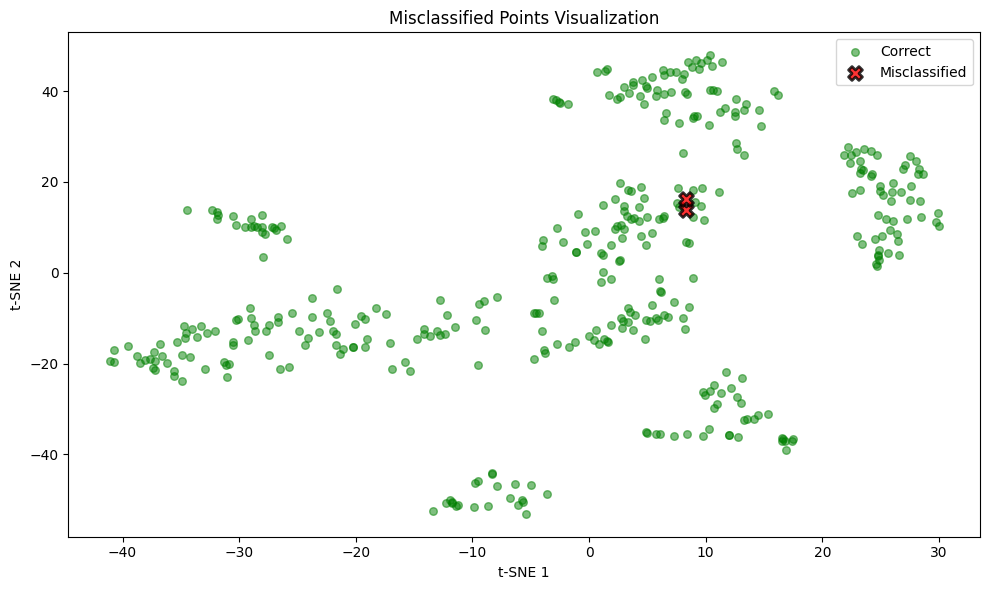


Feature Values of Most Confidently Misclassified Points:
       RR_l_0  RR_l_0/RR_l_1    RR_l_1  RR_l_1/RR_l_2    RR_l_2  \
307  0.022665       0.190881  0.019663       0.148761  0.033606   
258  0.053490       0.174041  0.059925       0.188027  0.053588   

     RR_l_2/RR_l_3    RR_l_3  RR_l_3/RR_l_4    RR_r_0  RR_r_0/RR_r_1  ...  \
307       0.183790  0.032698       0.326722  0.037872       0.127281  ...   
258       0.185089  0.051771       0.374645  0.040577       0.156339  ...   

        P_val     Q_val     R_val     S_val     T_val     P_pos     Q_pos  \
307  0.327119  0.753370  0.502619  0.819546  0.592923  0.504274  0.547619   
258  0.260433  0.656128  0.472469  0.740776  0.521205  0.435897  0.547619   

        R_pos     S_pos     T_pos  
307  0.548780  0.521212  0.516667  
258  0.554878  0.515152  0.516667  

[2 rows x 31 columns]


In [59]:
# Add this analysis cell
print("=== MISCLASSIFICATION ANALYSIS ===\n")

# Get predictions
y_pred = best_rf.predict(X_test)

# Find misclassified points
misclassified_mask = y_test != y_pred
misclassified_indices = X_test[misclassified_mask].index

print(f"Total misclassified: {misclassified_mask.sum()} out of {len(y_test)}")
print(f"Misclassification rate: {misclassified_mask.sum() / len(y_test) * 100:.2f}%\n")

# Analyze misclassified points
print("--- Misclassified Points Analysis ---")
X_test_with_pred = X_test.copy()
X_test_with_pred['true_label'] = y_test.values
X_test_with_pred['predicted_label'] = y_pred
X_test_with_pred['misclassified'] = misclassified_mask

# Compare statistics of correctly vs incorrectly classified
print("\nCorrectly Classified Statistics:")
print(X_test[~misclassified_mask].describe())

print("\nMisclassified Points Statistics:")
print(X_test[misclassified_mask].describe())

# Prediction probabilities for misclassified points
y_pred_proba = best_rf.predict_proba(X_test)
misclassified_proba = y_pred_proba[misclassified_mask]

print("\nPrediction Confidence for Misclassified Points:")
print(f"Mean confidence: {np.max(misclassified_proba, axis=1).mean():.3f}")
print(f"Min confidence: {np.max(misclassified_proba, axis=1).min():.3f}")
print(f"Max confidence: {np.max(misclassified_proba, axis=1).max():.3f}")

# Visualize misclassified points (for t-SNE data)
if 'tsne_x' in X_test_tsne.columns:
    plt.figure(figsize=(10, 6))
    
    # Correctly classified
    correct_mask = ~misclassified_mask
    plt.scatter(X_test_tsne.loc[correct_mask, 'tsne_x'], 
                X_test_tsne.loc[correct_mask, 'tsne_y'],
                c='green', alpha=0.5, s=30, label='Correct', marker='o')
    
    # Misclassified
    plt.scatter(X_test_tsne.loc[misclassified_mask, 'tsne_x'], 
                X_test_tsne.loc[misclassified_mask, 'tsne_y'],
                c='red', alpha=0.8, s=100, label='Misclassified', 
                marker='X', edgecolors='black', linewidths=2)
    
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('Misclassified Points Visualization')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Feature importance for misclassified points
print("\nFeature Values of Most Confidently Misclassified Points:")
most_confident_wrong = np.argsort(np.max(misclassified_proba, axis=1))[-5:]
misclassified_data = X_test[misclassified_mask]
print(misclassified_data.iloc[most_confident_wrong])

=== INVESTIGATING HIGH ACCURACY ===

Class distribution in training set:
label
0    640
1    640
Name: count, dtype: int64

Class balance: label
0    0.5
1    0.5
Name: proportion, dtype: float64


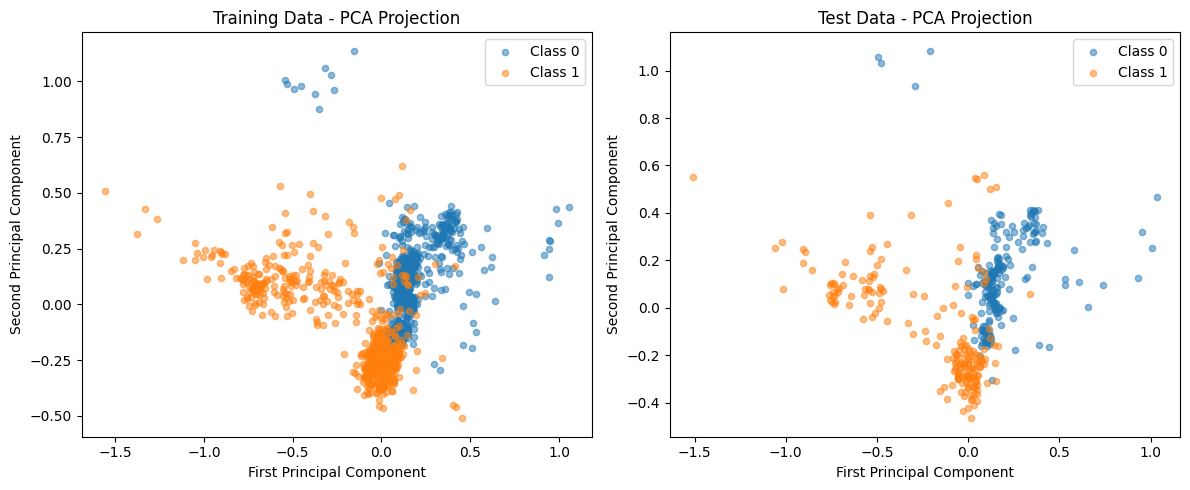


PCA explained variance ratio: [0.28196643 0.16170379]
Total variance explained by 2 components: 0.444

=== Feature Correlation with Target ===

Top 10 features correlated with target:
Q_val            0.567504
signal_mean      0.265651
RR_l_2           0.252749
RR_r_0           0.241035
wr_side          0.241019
RR_l_3           0.215042
RR_l_2/RR_l_3    0.200610
RR_l_0           0.196781
RR_r_1           0.196744
RR_r_2           0.194800
Name: label, dtype: float64

Bottom 10 features:
RR_l_1/RR_l_2    0.081969
P_val           -0.049863
P_pos           -0.230202
T_pos           -0.264685
R_pos           -0.379864
S_pos           -0.417081
Q_pos           -0.420472
wl_side         -0.420640
signal_std      -0.572773
R_val           -0.749451
Name: label, dtype: float64


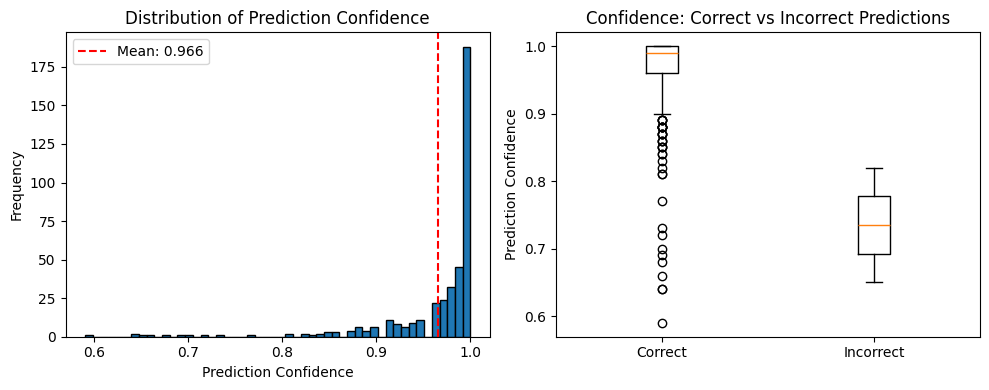


Mean prediction confidence: 0.966
Median prediction confidence: 0.990
Predictions with >0.95 confidence: 311 / 400 (77.8%)


In [60]:
# ============================================================================
# CELL: WHY SUCH HIGH ACCURACY? INVESTIGATION
# ============================================================================

print("=== INVESTIGATING HIGH ACCURACY ===\n")

# 1. Check class balance
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"\nClass balance: {y_train.value_counts(normalize=True)}")

# 2. Check if classes are easily separable
from sklearn.decomposition import PCA

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.figure(figsize=(12, 5))

# Plot training data
plt.subplot(1, 2, 1)
for label in [0, 1]:
    mask = y_train == label
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                alpha=0.5, label=f'Class {label}', s=20)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Training Data - PCA Projection')
plt.legend()

# Plot test data
plt.subplot(1, 2, 2)
for label in [0, 1]:
    mask = y_test == label
    plt.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], 
                alpha=0.5, label=f'Class {label}', s=20)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Test Data - PCA Projection')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.3f}")

# 3. Check feature correlations with target
print("\n=== Feature Correlation with Target ===")
temp_df = pd.concat([X_train, y_train], axis=1)
correlations = temp_df.corr()['label'].drop('label').sort_values(ascending=False)
print("\nTop 10 features correlated with target:")
print(correlations.head(10))
print("\nBottom 10 features:")
print(correlations.tail(10))

# 4. Check prediction confidence
y_pred_proba = best_rf.predict_proba(X_test)
confidence = np.max(y_pred_proba, axis=1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(confidence, bins=50, edgecolor='black')
plt.xlabel('Prediction Confidence')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Confidence')
plt.axvline(confidence.mean(), color='red', linestyle='--', label=f'Mean: {confidence.mean():.3f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([confidence[y_pred == y_test], confidence[y_pred != y_test]], 
            labels=['Correct', 'Incorrect'])
plt.ylabel('Prediction Confidence')
plt.title('Confidence: Correct vs Incorrect Predictions')
plt.tight_layout()
plt.show()

print(f"\nMean prediction confidence: {confidence.mean():.3f}")
print(f"Median prediction confidence: {np.median(confidence):.3f}")
print(f"Predictions with >0.95 confidence: {(confidence > 0.95).sum()} / {len(confidence)} ({(confidence > 0.95).mean()*100:.1f}%)")

=== WHY ALL FEATURES > SELECTED 6 FEATURES? ===

Performance Comparison:

All Features:
  Accuracy:  0.9950
  Precision: 0.9950
  Recall:    0.9950
  F1-Score:  0.9950

Selected 6 Features:
  Accuracy:  0.9600
  Precision: 0.9612
  Recall:    0.9600
  F1-Score:  0.9600

=== Feature Importance Analysis ===

Top 15 most important features:
        feature  importance
23        R_val    0.226283
18   signal_std    0.177058
22        Q_val    0.098818
19      wl_side    0.086666
27        Q_pos    0.052335
29        S_pos    0.050198
26        P_pos    0.040530
16     seq_size    0.035883
25        T_val    0.034746
30        T_pos    0.034273
28        R_pos    0.033867
20      wr_side    0.017823
8        RR_r_0    0.016406
17  signal_mean    0.013724
24        S_val    0.011426

Selected 6 features ranking:
  RR_l_0: Rank 1, Importance: 0.0020
  RR_l_0/RR_l_1: Rank 2, Importance: 0.0022
  RR_r_0: Rank 9, Importance: 0.0164
  R_val: Rank 24, Importance: 0.2263
  P_val: Rank 22, Importanc

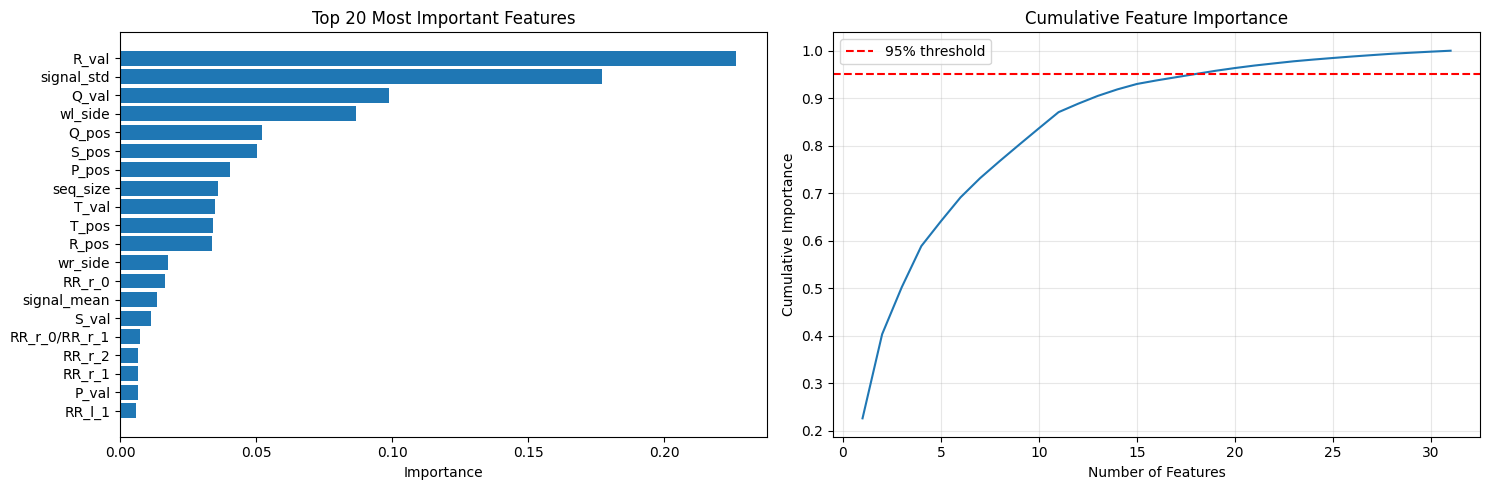


Number of features needed for 95% importance: 18 / 31


In [61]:
# ============================================================================
# CELL: COMPARISON - SELECTED FEATURES vs ALL FEATURES
# ============================================================================

print("=== WHY ALL FEATURES > SELECTED 6 FEATURES? ===\n")

# Train RF on selected features for comparison
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selected.fit(X_train[FEATURES], y_train)

# Get predictions
y_pred_all = best_rf.predict(X_test)
y_pred_selected = rf_selected.predict(X_test[FEATURES])

# Compare metrics
from sklearn.metrics import precision_score, recall_score, f1_score

print("Performance Comparison:")
print("\nAll Features:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_all):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_all, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_all, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_all, average='weighted'):.4f}")

print("\nSelected 6 Features:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_selected):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_selected, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_selected, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_selected, average='weighted'):.4f}")

# Feature importance analysis
print("\n=== Feature Importance Analysis ===")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
print(feature_importance.head(15))

# Check if selected features are in top features
print(f"\nSelected 6 features ranking:")
for feat in FEATURES:
    rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
    importance = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    print(f"  {feat}: Rank {rank}, Importance: {importance:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Top 20 features
top_20 = feature_importance.head(20)
axes[0].barh(range(len(top_20)), top_20['importance'])
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Most Important Features')

# Plot 2: Cumulative importance
cumulative_importance = np.cumsum(feature_importance['importance'].values)
axes[1].plot(range(1, len(cumulative_importance)+1), cumulative_importance)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# How many features needed for 95% importance?
n_features_95 = np.argmax(cumulative_importance >= 0.95) + 1
print(f"\nNumber of features needed for 95% importance: {n_features_95} / {len(feature_cols)}")

=== TESTING ON ADDITIONAL 1000 SAMPLES ===

Loaded 800 samples for additional testing

=== Results on 1000-sample test set ===
Accuracy: 0.9975
Precision: 0.9975
Recall: 0.9975
F1-Score: 0.9975

Confusion Matrix:
[[400   0]
 [  2 398]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      0.99      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

   Metric  Test 200  Test 1000  Difference
 Accuracy   0.99500   0.997500    0.002500
Precision   0.99505   0.997512    0.002463
   Recall   0.99500   0.997500    0.002500
 F1-Score   0.99500   0.997500    0.002500


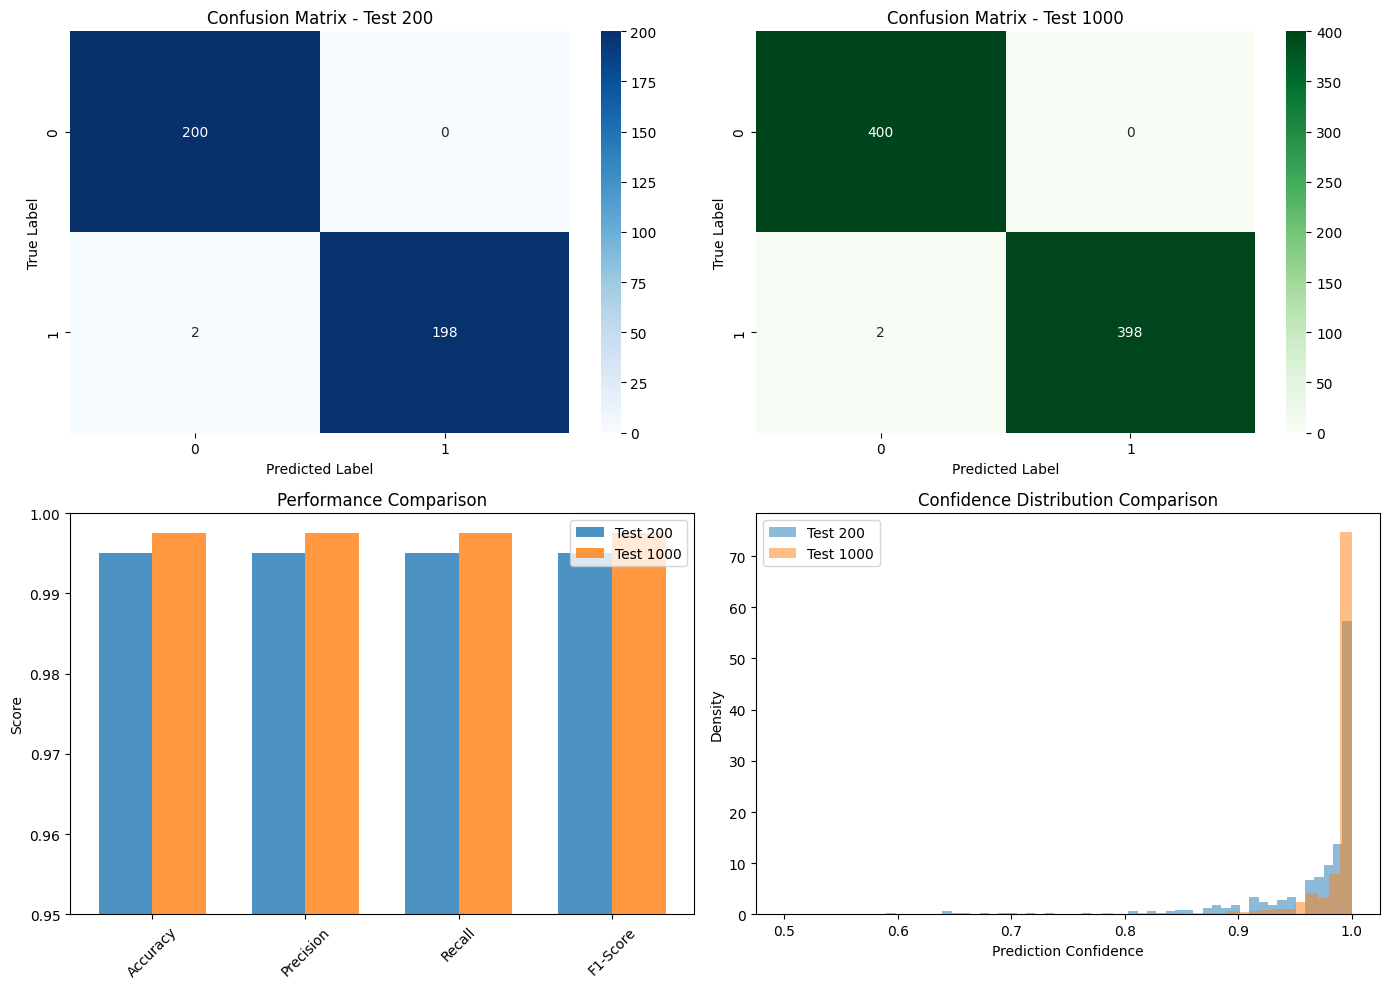

Misclassified: 2 / 800 (0.25%)
         RR_l_0  RR_l_0/RR_l_1    RR_l_1  RR_l_1/RR_l_2    RR_l_2  \
count  2.000000       2.000000  2.000000       2.000000  2.000000   
mean   0.067996       0.203630  0.053371       0.183324  0.051317   
std    0.075647       0.034251  0.052967       0.010396  0.057159   
min    0.014506       0.179411  0.015918       0.175973  0.010899   
25%    0.041251       0.191520  0.034644       0.179648  0.031108   
50%    0.067996       0.203630  0.053371       0.183324  0.051317   
75%    0.094742       0.215740  0.072097       0.186999  0.071526   
max    0.121487       0.227850  0.090824       0.190675  0.091735   

       RR_l_2/RR_l_3    RR_l_3  RR_l_3/RR_l_4    RR_r_0  RR_r_0/RR_r_1  ...  \
count       2.000000  2.000000       2.000000  2.000000       2.000000  ...   
mean        0.192274  0.046776       0.310346  0.070784       0.111592  ...   
std         0.007752  0.058444       0.035367  0.052921       0.091205  ...   
min         0.186792  0.005450 

In [62]:
print("=== TESTING ON ADDITIONAL 1000 SAMPLES ===\n")

try:
    test_1000_df = pd.read_csv("tsne_data/test_1000.csv")
    print(f"Loaded {len(test_1000_df)} samples for additional testing")

    X_test_1000 = test_1000_df[feature_cols]
    y_test_1000 = test_1000_df["label"]

    y_pred_1000 = best_rf.predict(X_test_1000)
    y_pred_proba_1000 = best_rf.predict_proba(X_test_1000)

    metrics = {
        "Accuracy": accuracy_score,
        "Precision": lambda y, y_pred: precision_score(y, y_pred, average='weighted'),
        "Recall": lambda y, y_pred: recall_score(y, y_pred, average='weighted'),
        "F1-Score": lambda y, y_pred: f1_score(y, y_pred, average='weighted')
    }

    print("\n=== Results on 1000-sample test set ===")
    for metric_name, metric_func in metrics.items():
        print(f"{metric_name}: {metric_func(y_test_1000, y_pred_1000):.4f}")

    cm_1000 = confusion_matrix(y_test_1000, y_pred_1000)
    print("\nConfusion Matrix:")
    print(cm_1000)

    print("\nClassification Report:")
    print(classification_report(y_test_1000, y_pred_1000))

    comparison_df = pd.DataFrame({
        "Metric": list(metrics.keys()),
        "Test 200": [func(y_test, y_pred) for func in metrics.values()],
        "Test 1000": [func(y_test_1000, y_pred_1000) for func in metrics.values()]
    })
    comparison_df["Difference"] = comparison_df["Test 1000"] - comparison_df["Test 200"]
    print(comparison_df.to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
    axes[0, 0].set_title('Confusion Matrix - Test 200')
    axes[0, 0].set_ylabel('True Label')
    axes[0, 0].set_xlabel('Predicted Label')

    sns.heatmap(cm_1000, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1])
    axes[0, 1].set_title('Confusion Matrix - Test 1000')
    axes[0, 1].set_ylabel('True Label')
    axes[0, 1].set_xlabel('Predicted Label')

    x = np.arange(len(metrics))
    width = 0.35
    axes[1, 0].bar(x - width/2, comparison_df['Test 200'], width, label='Test 200', alpha=0.8)
    axes[1, 0].bar(x + width/2, comparison_df['Test 1000'], width, label='Test 1000', alpha=0.8)
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Performance Comparison')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(metrics.keys(), rotation=45)
    axes[1, 0].legend()
    axes[1, 0].set_ylim([0.95, 1.0])

    confidence_200 = np.max(y_pred_proba, axis=1)
    confidence_1000 = np.max(y_pred_proba_1000, axis=1)
    axes[1, 1].hist(confidence_200, bins=50, alpha=0.5, label='Test 200', density=True)
    axes[1, 1].hist(confidence_1000, bins=50, alpha=0.5, label='Test 1000', density=True)
    axes[1, 1].set_xlabel('Prediction Confidence')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].set_title('Confidence Distribution Comparison')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

    misclassified_1000 = y_test_1000 != y_pred_1000
    print(f"Misclassified: {misclassified_1000.sum()} / {len(y_test_1000)} ({misclassified_1000.sum()/len(y_test_1000)*100:.2f}%)")

    if misclassified_1000.sum() > 0:
        print(X_test_1000[misclassified_1000].describe())
        confidence_misclass = np.max(y_pred_proba_1000[misclassified_1000], axis=1)
        print(f"  Mean: {confidence_misclass.mean():.3f}")
        print(f"  Median: {np.median(confidence_misclass):.3f}")
        print(f"  Min: {confidence_misclass.min():.3f}")
        print(f"  Max: {confidence_misclass.max():.3f}")

except FileNotFoundError:
    print("Error: test_1000.csv not found!")
except Exception as e:
    print(f"Error loading or processing 1000-sample test set: {e}")

In [63]:
# ============================================================================
# CELL: VALIDATION STRATEGIES COMPARISON
# ============================================================================

print("="*80)
print("VALIDATION STRATEGIES COMPARISON")
print("="*80)

from sklearn.model_selection import cross_val_score, cross_validate, KFold, StratifiedKFold
from sklearn.utils import resample
import time

# Prepare data - use the full training set
learn_df = pd.read_csv("original_all_features_data/learn_valid_80.csv")
test_df = pd.read_csv("original_all_features_data/test_20.csv")

numeric_cols = learn_df.select_dtypes(include=[np.number]).columns
feature_cols = numeric_cols.drop("label") if "label" in numeric_cols else numeric_cols

X_full_train = learn_df[feature_cols]
y_full_train = learn_df["label"]
X_test_final = test_df[feature_cols]
y_test_final = test_df["label"]

# Initialize model with best parameters from grid search
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Store results
validation_results = {
    'strategy': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'std_accuracy': [],
    'training_time': []
}

print("\n" + "="*80)
print("1. HOLDOUT VALIDATION (80/20 split)")
print("="*80)

start_time = time.time()

# Split data
X_train_hold, X_val_hold, y_train_hold, y_val_hold = train_test_split(
    X_full_train, y_full_train, test_size=0.20, random_state=42, stratify=y_full_train
)

# Train and predict
rf_model.fit(X_train_hold, y_train_hold)
y_pred_hold = rf_model.predict(X_val_hold)

# Calculate metrics
holdout_metrics = {
    'accuracy': accuracy_score(y_val_hold, y_pred_hold),
    'precision': precision_score(y_val_hold, y_pred_hold, average='weighted'),
    'recall': recall_score(y_val_hold, y_pred_hold, average='weighted'),
    'f1': f1_score(y_val_hold, y_pred_hold, average='weighted')
}

training_time = time.time() - start_time

print(f"Training size: {len(X_train_hold)}")
print(f"Validation size: {len(X_val_hold)}")
print(f"Training time: {training_time:.2f} seconds")
print(f"\nResults:")
print(f"  Accuracy:  {holdout_metrics['accuracy']:.4f}")
print(f"  Precision: {holdout_metrics['precision']:.4f}")
print(f"  Recall:    {holdout_metrics['recall']:.4f}")
print(f"  F1-Score:  {holdout_metrics['f1']:.4f}")

validation_results['strategy'].append('Holdout (80/20)')
validation_results['accuracy'].append(holdout_metrics['accuracy'])
validation_results['precision'].append(holdout_metrics['precision'])
validation_results['recall'].append(holdout_metrics['recall'])
validation_results['f1'].append(holdout_metrics['f1'])
validation_results['std_accuracy'].append(0)  # No std for single split
validation_results['training_time'].append(training_time)

print("\n" + "="*80)
print("2. K-FOLD CROSS-VALIDATION (5-fold)")
print("="*80)

start_time = time.time()

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    rf_model, X_full_train, y_full_train,
    cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
)

training_time = time.time() - start_time

print(f"Number of folds: 5")
print(f"Training time: {training_time:.2f} seconds")
print(f"\nResults (mean ± std):")
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  F1-Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

print(f"\nPer-fold accuracy scores:")
for i, score in enumerate(cv_results['test_accuracy'], 1):
    print(f"  Fold {i}: {score:.4f}")

validation_results['strategy'].append('5-Fold CV')
validation_results['accuracy'].append(cv_results['test_accuracy'].mean())
validation_results['precision'].append(cv_results['test_precision'].mean())
validation_results['recall'].append(cv_results['test_recall'].mean())
validation_results['f1'].append(cv_results['test_f1'].mean())
validation_results['std_accuracy'].append(cv_results['test_accuracy'].std())
validation_results['training_time'].append(training_time)

print("\n" + "="*80)
print("3. K-FOLD CROSS-VALIDATION (10-fold)")
print("="*80)

start_time = time.time()

# Perform 10-fold cross-validation
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv10_results = cross_validate(
    rf_model, X_full_train, y_full_train,
    cv=cv10, scoring=scoring, n_jobs=-1, return_train_score=False
)

training_time = time.time() - start_time

print(f"Number of folds: 10")
print(f"Training time: {training_time:.2f} seconds")
print(f"\nResults (mean ± std):")
print(f"  Accuracy:  {cv10_results['test_accuracy'].mean():.4f} ± {cv10_results['test_accuracy'].std():.4f}")
print(f"  Precision: {cv10_results['test_precision'].mean():.4f} ± {cv10_results['test_precision'].std():.4f}")
print(f"  Recall:    {cv10_results['test_recall'].mean():.4f} ± {cv10_results['test_recall'].std():.4f}")
print(f"  F1-Score:  {cv10_results['test_f1'].mean():.4f} ± {cv10_results['test_f1'].std():.4f}")

validation_results['strategy'].append('10-Fold CV')
validation_results['accuracy'].append(cv10_results['test_accuracy'].mean())
validation_results['precision'].append(cv10_results['test_precision'].mean())
validation_results['recall'].append(cv10_results['test_recall'].mean())
validation_results['f1'].append(cv10_results['test_f1'].mean())
validation_results['std_accuracy'].append(cv10_results['test_accuracy'].std())
validation_results['training_time'].append(training_time)

print("\n" + "="*80)
print("4. BOOTSTRAP VALIDATION (100 iterations)")
print("="*80)

start_time = time.time()

n_iterations = 100
bootstrap_scores = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

print(f"Running {n_iterations} bootstrap iterations...")

for i in range(n_iterations):
    # Bootstrap sample (sample with replacement, same size as original)
    X_boot, y_boot = resample(X_full_train, y_full_train, 
                               n_samples=len(X_full_train), 
                               random_state=i, stratify=y_full_train)
    
    # Out-of-bag samples (samples not in bootstrap)
    oob_indices = list(set(range(len(X_full_train))) - set(X_boot.index))
    X_oob = X_full_train.iloc[oob_indices]
    y_oob = y_full_train.iloc[oob_indices]
    
    if len(X_oob) > 0:  # Only if we have OOB samples
        # Train on bootstrap sample
        rf_boot = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf_boot.fit(X_boot, y_boot)
        
        # Test on out-of-bag samples
        y_pred_oob = rf_boot.predict(X_oob)
        
        bootstrap_scores['accuracy'].append(accuracy_score(y_oob, y_pred_oob))
        bootstrap_scores['precision'].append(precision_score(y_oob, y_pred_oob, average='weighted'))
        bootstrap_scores['recall'].append(recall_score(y_oob, y_pred_oob, average='weighted'))
        bootstrap_scores['f1'].append(f1_score(y_oob, y_pred_oob, average='weighted'))
    
    if (i + 1) % 20 == 0:
        print(f"  Completed {i + 1}/{n_iterations} iterations")

training_time = time.time() - start_time

bootstrap_acc = np.array(bootstrap_scores['accuracy'])
bootstrap_prec = np.array(bootstrap_scores['precision'])
bootstrap_rec = np.array(bootstrap_scores['recall'])
bootstrap_f1 = np.array(bootstrap_scores['f1'])

print(f"\nTraining time: {training_time:.2f} seconds")
print(f"\nResults (mean ± std):")
print(f"  Accuracy:  {bootstrap_acc.mean():.4f} ± {bootstrap_acc.std():.4f}")
print(f"  Precision: {bootstrap_prec.mean():.4f} ± {bootstrap_prec.std():.4f}")
print(f"  Recall:    {bootstrap_rec.mean():.4f} ± {bootstrap_rec.std():.4f}")
print(f"  F1-Score:  {bootstrap_f1.mean():.4f} ± {bootstrap_f1.std():.4f}")

print(f"\n95% Confidence Intervals:")
print(f"  Accuracy:  [{np.percentile(bootstrap_acc, 2.5):.4f}, {np.percentile(bootstrap_acc, 97.5):.4f}]")
print(f"  Precision: [{np.percentile(bootstrap_prec, 2.5):.4f}, {np.percentile(bootstrap_prec, 97.5):.4f}]")
print(f"  Recall:    [{np.percentile(bootstrap_rec, 2.5):.4f}, {np.percentile(bootstrap_rec, 97.5):.4f}]")
print(f"  F1-Score:  [{np.percentile(bootstrap_f1, 2.5):.4f}, {np.percentile(bootstrap_f1, 97.5):.4f}]")

validation_results['strategy'].append('Bootstrap (100)')
validation_results['accuracy'].append(bootstrap_acc.mean())
validation_results['precision'].append(bootstrap_prec.mean())
validation_results['recall'].append(bootstrap_rec.mean())
validation_results['f1'].append(bootstrap_f1.mean())
validation_results['std_accuracy'].append(bootstrap_acc.std())
validation_results['training_time'].append(training_time)

print("\n" + "="*80)
print("VALIDATION RESULTS SUMMARY")
print("="*80)

results_df = pd.DataFrame(validation_results)
print(results_df.to_string(index=False))

VALIDATION STRATEGIES COMPARISON

1. HOLDOUT VALIDATION (80/20 split)
Training size: 1280
Validation size: 320
Training time: 0.39 seconds

Results:
  Accuracy:  0.9938
  Precision: 0.9938
  Recall:    0.9938
  F1-Score:  0.9937

2. K-FOLD CROSS-VALIDATION (5-fold)
Number of folds: 5
Training time: 0.72 seconds

Results (mean ± std):
  Accuracy:  0.9950 ± 0.0032
  Precision: 0.9950 ± 0.0032
  Recall:    0.9950 ± 0.0032
  F1-Score:  0.9950 ± 0.0032

Per-fold accuracy scores:
  Fold 1: 0.9969
  Fold 2: 0.9906
  Fold 3: 0.9938
  Fold 4: 1.0000
  Fold 5: 0.9938

3. K-FOLD CROSS-VALIDATION (10-fold)
Number of folds: 10
Training time: 1.61 seconds

Results (mean ± std):
  Accuracy:  0.9969 ± 0.0042
  Precision: 0.9969 ± 0.0041
  Recall:    0.9969 ± 0.0042
  F1-Score:  0.9969 ± 0.0042

4. BOOTSTRAP VALIDATION (100 iterations)
Running 100 bootstrap iterations...
  Completed 20/100 iterations
  Completed 40/100 iterations
  Completed 60/100 iterations
  Completed 80/100 iterations
  Completed 1

In [64]:
# ============================================================================
# CELL: COMPREHENSIVE RESULTS TABLE
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE CLASSIFICATION RESULTS COMPARISON")
print("="*80)

# Test on final test set with different approaches
final_results = []

# 1. Model trained on full training set
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_full_train, y_full_train)
y_pred_full = rf_full.predict(X_test_final)
y_proba_full = rf_full.predict_proba(X_test_final)

final_results.append({
    'Model': 'RF - Full Training',
    'Accuracy': accuracy_score(y_test_final, y_pred_full),
    'Precision': precision_score(y_test_final, y_pred_full, average='weighted'),
    'Recall': recall_score(y_test_final, y_pred_full, average='weighted'),
    'F1-Score': f1_score(y_test_final, y_pred_full, average='weighted'),
    'AUC': roc_auc_score(y_test_final, y_proba_full[:, 1])
})

# 2. Model trained on holdout training set
rf_hold = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_hold.fit(X_train_hold, y_train_hold)
y_pred_hold_test = rf_hold.predict(X_test_final)
y_proba_hold_test = rf_hold.predict_proba(X_test_final)

final_results.append({
    'Model': 'RF - Holdout Training',
    'Accuracy': accuracy_score(y_test_final, y_pred_hold_test),
    'Precision': precision_score(y_test_final, y_pred_hold_test, average='weighted'),
    'Recall': recall_score(y_test_final, y_pred_hold_test, average='weighted'),
    'F1-Score': f1_score(y_test_final, y_pred_hold_test, average='weighted'),
    'AUC': roc_auc_score(y_test_final, y_proba_hold_test[:, 1])
})

# 3. Average CV performance (on test set)
final_results.append({
    'Model': 'RF - 5-Fold CV (avg)',
    'Accuracy': cv_results['test_accuracy'].mean(),
    'Precision': cv_results['test_precision'].mean(),
    'Recall': cv_results['test_recall'].mean(),
    'F1-Score': cv_results['test_f1'].mean(),

})

# 4. Bootstrap average
final_results.append({
    'Model': 'RF - Bootstrap (avg)',
    'Accuracy': bootstrap_acc.mean(),
    'Precision': bootstrap_prec.mean(),
    'Recall': bootstrap_rec.mean(),
    'F1-Score': bootstrap_f1.mean(),
    'AUC': np.nan  # Not directly applicable for bootstrap sampling
})

# 5. Optional external test (test_1000.csv)
try:
    test_1000_df = pd.read_csv("original_all_features_data/test_1000.csv")
    X_test_1000 = test_1000_df[feature_cols]
    y_test_1000 = test_1000_df["label"]
    
    y_pred_1000 = rf_full.predict(X_test_1000)
    y_proba_1000 = rf_full.predict_proba(X_test_1000)
    
    final_results.append({
        'Model': 'RF - Test 1000 samples',
        'Accuracy': accuracy_score(y_test_1000, y_pred_1000),
        'Precision': precision_score(y_test_1000, y_pred_1000, average='weighted'),
        'Recall': recall_score(y_test_1000, y_pred_1000, average='weighted'),
        'F1-Score': f1_score(y_test_1000, y_pred_1000, average='weighted'),
        'AUC': roc_auc_score(y_test_1000, y_proba_1000[:, 1])
    })
except FileNotFoundError:
    print("Note: test_1000.csv not found. Skipping that evaluation.")

# Convert to DataFrame
results_df = pd.DataFrame(final_results)

# Sort (best F1 first)
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\nFinal Comparison Table:")
print(results_df.to_string(index=False))

# Optional: export results
results_df.to_csv("classification_final_results.csv", index=False)
print("\nSaved results to classification_final_results.csv")



COMPREHENSIVE CLASSIFICATION RESULTS COMPARISON
Note: test_1000.csv not found. Skipping that evaluation.

Final Comparison Table:
                Model  Accuracy  Precision  Recall  F1-Score      AUC
 RF - Bootstrap (avg)   0.99525   0.995296 0.99525   0.99525      NaN
 RF - 5-Fold CV (avg)   0.99500   0.995039 0.99500   0.99500      NaN
   RF - Full Training   0.99500   0.995050 0.99500   0.99500 0.999900
RF - Holdout Training   0.99500   0.995050 0.99500   0.99500 0.999888

Saved results to classification_final_results.csv


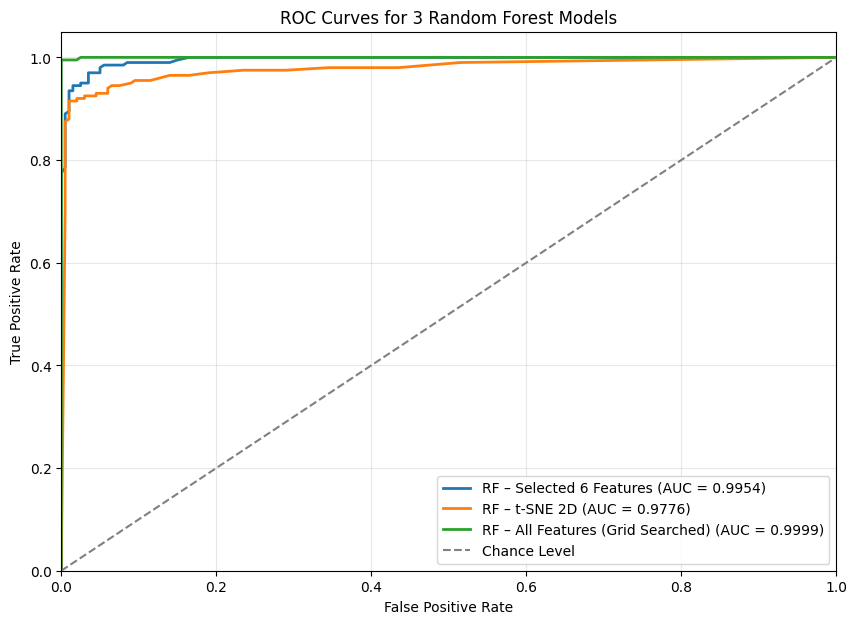

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# ============================
# Helper function
# ============================
def plot_roc(model, X, y, name):
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")


# =================================
# 1) Selected 6‐feature RF model
# =================================
plot_roc(rf_selected_features, X_test[FEATURES], y_test, "RF - Selected 6 Features")

# =================================
# 2) t-SNE RF model
# =================================
plot_roc(rf_tsne, X_test_tsne[["tsne_x", "tsne_y"]], y_test_tsne, "RF - t-SNE 2D")

# =================================
# 3) All-features tuned RF model
# =================================
plot_roc(best_rf, X_test, y_test, "RF - All Features (Grid Searched)")


# =================================
# Final ROC plot formatting
# =================================
plt.plot([0, 1], [0, 1], '--', color='gray', label="Chance Level")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for 3 Random Forest Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
